# TER Picopatt - Prediction

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
from dotenv import load_dotenv

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

import functions as fc
from functions import load_all

In [2]:
OUT = Path("outputs")
fc.create_folder(OUT)

FIG = Path(OUT, "figures/tmrt_pred")
fc.create_folder(FIG)

MFDATA = Path(OUT / "meteofrance_data")
fc.create_folder(MFDATA)

FIG_MODELS = FIG / "models"
FIG_ERRORS = FIG / "errors"
FIG_DATA   = FIG / "data_quality"

fc.create_folder(FIG_MODELS)
fc.create_folder(FIG_ERRORS)
fc.create_folder(FIG_DATA)

print("OUT:", OUT)
print("FIG:", FIG)
print("MFDATA:", MFDATA)

OUT: outputs
FIG: outputs\figures\tmrt_pred
MFDATA: outputs\meteofrance_data


In [3]:
DATA_NOZERO = Path("outputs/clean_nozeros")
bd = load_all(DATA_NOZERO, False)

required_geo = ["lon_ontrack", "lat_ontrack"]
missing_geo = [c for c in required_geo if c not in bd.columns]
if missing_geo:
    raise ValueError("Colonnes GNSS ontrack manquantes: " + ", ".join(missing_geo))

bd = bd.copy()
bd["lon_std"] = pd.to_numeric(bd["lon_ontrack"], errors="coerce")
bd["lat_std"] = pd.to_numeric(bd["lat_ontrack"], errors="coerce")

bd = bd.dropna(subset=["lon_std", "lat_std"])
bd = bd[(bd["lon_std"].between(-180, 180)) & (bd["lat_std"].between(-90, 90))]

bd = bd.reset_index(drop=True)
bd["uid"] = bd.index.astype(int)

print("bd ready:", bd.shape)
print(bd[["uid","lon_std","lat_std"]].head())


bd ready: (341281, 42)
   uid   lon_std    lat_std
0    0  3.886345  43.608305
1    1  3.886353  43.608305
2    2  3.886361  43.608304
3    3  3.886369  43.608304
4    4  3.886377  43.608303


In [4]:
AE = Path("outputs/alphaearth_data")

# Fichiers exports AlphaEarth
raw_path  = AE / "alphaearth_A00_A63_points.csv"
pca10_path = AE / "alphaearth_pca10_points.csv"
pca15_path = AE / "alphaearth_pca15_points.csv"
pca32_path = AE / "alphaearth_pca32_points.csv"

for p in [raw_path, pca10_path, pca15_path, pca32_path]:
    if not p.exists():
        raise FileNotFoundError(f"Fichier manquant: {p}")

aef_raw  = pd.read_csv(raw_path)
aef_pca10 = pd.read_csv(pca10_path)
aef_pca15 = pd.read_csv(pca15_path)
aef_pca32 = pd.read_csv(pca32_path)

# Noms des colonnes
BANDS = [f"A{i:02d}" for i in range(64)]
PCA10_COLS = [c for c in aef_pca10.columns if c.startswith("aef_pca10_")]
PCA15_COLS = [c for c in aef_pca15.columns if c.startswith("aef_pca15_")]
PCA32_COLS = [c for c in aef_pca32.columns if c.startswith("aef_pca32_")]

# Merge dans bd
df = bd.merge(aef_raw[["uid"] + BANDS], on="uid", how="left")
df = df.merge(aef_pca10[["uid"] + PCA10_COLS], on="uid", how="left")
df = df.merge(aef_pca15[["uid"] + PCA15_COLS], on="uid", how="left")
df = df.merge(aef_pca32[["uid"] + PCA32_COLS], on="uid", how="left")

print("df merged shape:", df.shape)
print("NaN embeddings raw A00:", int(df["A00"].isna().sum()))
print("NaN PCA10:", int(df[PCA10_COLS].isna().any(axis=1).sum()))

df merged shape: (341281, 163)
NaN embeddings raw A00: 0
NaN PCA10: 0


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp", "tmrt"]).copy()

start = df["timestamp"].min()
end   = df["timestamp"].max()
print("PICOPATT range:", start, "->", end)

PICOPATT range: 2024-10-29 08:36:30 -> 2025-01-16 19:26:41


Doit créer un compte sur https://public-api.meteofrance.fr/ puis mettre le token dans .env

In [6]:
load_dotenv()
TOKEN = os.getenv("MFTOKEN","").strip()
print("Token length:", len(TOKEN))
if len(TOKEN) <= 1400:
    raise ValueError("MFTOKEN trop court. Vérifie .env (et pas tronqué).")

BASE = "https://public-api.meteofrance.fr/public/DPClim/v1"
headers = {"apikey": TOKEN}

params_cmd = {
    "id-station": "34154001",  # MONTPELLIER-AEROPORT
    "date-deb-periode": "2024-10-29T00:00:00Z",
    "date-fin-periode": "2025-01-16T23:59:59Z"
}

r = requests.get(f"{BASE}/commande-station/horaire", headers=headers, params=params_cmd, timeout=120)
print("commande status:", r.status_code, r.text[:200])
r.raise_for_status()

cmd = r.json()
num_cmde = cmd["elaboreProduitAvecDemandeResponse"]["return"]
print("num_cmde:", num_cmde)


Token length: 1522
commande status: 202 {"elaboreProduitAvecDemandeResponse": {"return": "2026005626698"}}
num_cmde: 2026005626698


In [ ]:
def download_cmd_csv(num_cmde: str, out_path: Path, max_wait_s: int = 900, sleep_s: int = 5):
    t0 = time.time()
    out_path = Path(out_path)

    while True:
        rf = requests.get(
            f"{BASE}/commande/fichier",
            headers=headers,
            params={"id-cmde": num_cmde},
            timeout=120
        )

        if rf.status_code == 201 and len(rf.content) > 0:
            out_path.write_bytes(rf.content)
            return out_path

        if rf.status_code == 204:
            pass
        elif rf.status_code == 410:
            raise RuntimeError("410: production déjà livrée. Relance une commande pour un nouveau fichier.")
        elif rf.status_code == 404:
            raise RuntimeError("404: commande inconnue. Vérifie num_cmde.")
        elif rf.status_code == 507:
            raise RuntimeError("507: production trop volumineuse. Réduis la période.")
        elif rf.status_code >= 400:
            raise RuntimeError(f"Erreur {rf.status_code}: {rf.text[:300]}")

        if time.time() - t0 > max_wait_s:
            raise TimeoutError(f"Fichier non prêt après {max_wait_s}s. Dernier status={rf.status_code}")

        time.sleep(sleep_s)

mf_csv = MFDATA / f"mf_montpellier_{num_cmde}.csv"
mf_csv = download_cmd_csv(num_cmde, mf_csv)
print("CSV météo écrit:", mf_csv)

RuntimeError: 410: production déjà livrée. Relance une commande pour un nouveau fichier.

In [7]:
wx = pd.read_csv(MFDATA / "mf_montpellier_2026004655806.csv", sep=";", dtype=str)

wx["DATE"] = pd.to_datetime(wx["DATE"], format="%Y%m%d%H", utc=True)

num_cols = [c for c in wx.columns if c not in ["POSTE", "DATE"]]
for c in num_cols:
    wx[c] = wx[c].str.replace(",", ".", regex=False).replace({"": None})
    wx[c] = pd.to_numeric(wx[c], errors="coerce")

wx = wx.sort_values("DATE").reset_index(drop=True)

print("wx shape:", wx.shape)
print("wx cols:", len(wx.columns))
display(wx.head(3))

wx shape: (1920, 196)
wx cols: 196


,POSTE,DATE,RR1,QRR1,DRR1,QDRR1,HNEIGEF,QHNEIGEF,NEIGETOT,QNEIGETOT,...,UV2,QUV2,INS2,QINS2,INFRAR2,QINFRAR2,DIR2,QDIR2,DIF2,QDIF2
0,34154001,2024-10-29 00:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN
1,34154001,2024-10-29 01:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN
2,34154001,2024-10-29 02:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df2 = df.copy()
df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")

# Hypothèse (à garder explicite): timestamp PICOPATT en Europe/Paris si naïf
if df2["timestamp"].dt.tz is None:
    df2["timestamp"] = df2["timestamp"].dt.tz_localize("Europe/Paris")

df2["timestamp_utc"] = df2["timestamp"].dt.tz_convert("UTC")

df2 = df2.sort_values("timestamp_utc")
wx2 = wx.sort_values("DATE")

dfm = pd.merge_asof(
    df2,
    wx2,
    left_on="timestamp_utc",
    right_on="DATE",
    direction="nearest",
    tolerance=pd.Timedelta("30min")
)

print("dfm shape:", dfm.shape)
print("missing MF join:", float(dfm["DATE"].isna().mean()))


dfm shape: (341281, 360)
missing MF join: 0.0


In [9]:
# Variables MF utilisées
mf_base = [
    "T",      # température
    "U",      # humidité relative
    "PSTAT",  # pression station
    "FF", "DD", "FXI",  # vent + rafales
    "RR1",    # pluie (mm/1h)
    "N",      # nébulosité totale
    "INS",    # durée d’ensoleillement
    "GLO", "DIR", "DIF",  # rayonnement global/direct/diffus 
    "WW",     # temps présent (code)
    "VV"      # visibilité
]

mf_base = [c for c in mf_base if c in dfm.columns]

# Qualité: colonnes Qxxx associées si présentes
mf_q = [f"Q{c}" for c in mf_base if f"Q{c}" in dfm.columns]

# Option robuste: indicateurs de "manquant"
mf_missing_flags = []
for c in mf_base:
    flag = f"{c}_missing"
    dfm[flag] = dfm[c].isna().astype(int)
    mf_missing_flags.append(flag)

mf_features = mf_base + mf_q + mf_missing_flags

print("MF base:", mf_base)
print("MF quality cols:", mf_q[:10], "… total", len(mf_q))
print("MF features total:", len(mf_features))

MF base: ['T', 'U', 'PSTAT', 'FF', 'DD', 'FXI', 'RR1', 'N', 'INS', 'GLO', 'DIR', 'DIF', 'WW', 'VV']
MF quality cols: ['QT', 'QU', 'QPSTAT', 'QFF', 'QDD', 'QFXI', 'QRR1', 'QN', 'QINS', 'QGLO'] … total 14
MF features total: 42


In [10]:
def drop_all_nan_cols(df_, cols):
    cols = [c for c in cols if c in df_.columns]
    keep = [c for c in cols if df_[c].notna().any()]
    dropped = sorted(set(cols) - set(keep))
    return keep, dropped

TARGET = "tmrt"

ae_pca10 = [c for c in dfm.columns if c.startswith("aef_pca10_")]
ae_raw   = [f"A{i:02d}" for i in range(64) if f"A{i:02d}" in dfm.columns]

train = dfm.dropna(subset=[TARGET, "DATE"]).copy()
train["day_utc"] = train["timestamp_utc"].dt.floor("D")

mf_features, dropped_mf = drop_all_nan_cols(train, mf_features)
ae_pca10, dropped_p10 = drop_all_nan_cols(train, ae_pca10)
ae_raw, dropped_raw = drop_all_nan_cols(train, ae_raw)

print("train:", train.shape)
print("Dropped MF all-NaN:", dropped_mf)
print("Dropped AE PCA10 all-NaN:", dropped_p10)
print("Dropped AE raw all-NaN:", dropped_raw)

train: (341281, 375)
Dropped MF all-NaN: ['DIF', 'DIR', 'QDIF', 'QDIR']
Dropped AE PCA10 all-NaN: []
Dropped AE raw all-NaN: []


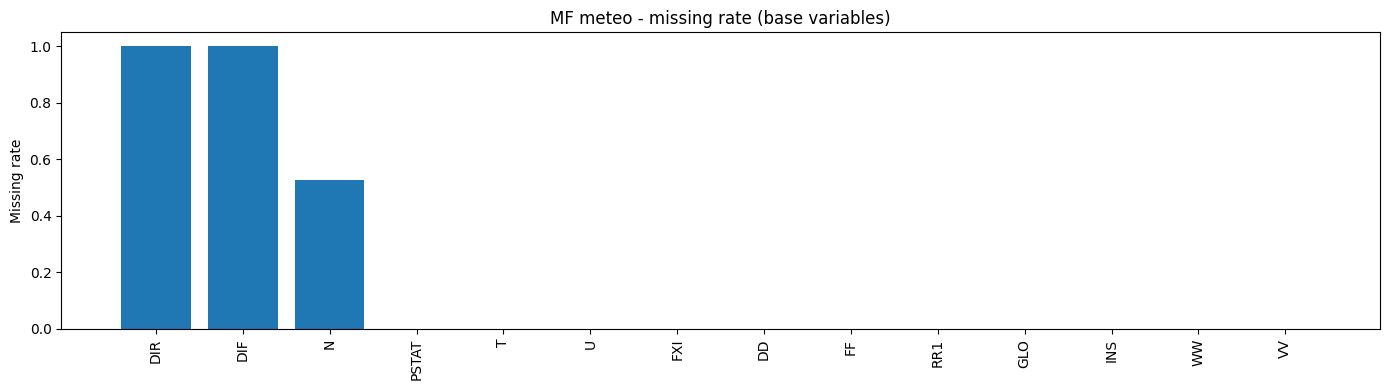

Figure enregistrée: outputs\figures\tmrt_pred\data_quality\mf_missing_rate.png


In [11]:
miss = train[mf_base].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(14,4))
plt.bar(miss.index, miss.values)
plt.xticks(rotation=90)
plt.ylabel("Missing rate")
plt.title("MF meteo - missing rate (base variables)")
plt.tight_layout()

out_fig = FIG_DATA / "mf_missing_rate.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

In [12]:
from sklearn.model_selection import GroupShuffleSplit

train["day_utc"] = train["timestamp_utc"].dt.floor("D")
groups = train["day_utc"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

def make_split(X, y):
    tr, te = next(gss.split(X, y, groups=groups))
    return tr, te


In [13]:
groups = train["day_utc"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

def make_split(X, y):
    tr, te = next(gss.split(X, y, groups=groups))
    return tr, te

In [14]:
def eval_set(name, feat_cols):
    X = train[feat_cols]
    y = train[TARGET].astype(float)

    tr, te = make_split(X, y)

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", HistGradientBoostingRegressor(random_state=42))
    ])

    model.fit(X.iloc[tr], y.iloc[tr])
    pred = model.predict(X.iloc[te])

    return {
        "set": name,
        "rmse": mean_squared_error(y.iloc[te], pred) ** 0.5,
        "mae": mean_absolute_error(y.iloc[te], pred),
        "r2": r2_score(y.iloc[te], pred),
        "n_test": len(te)
    }, (tr, te)

results = []
splits = {}

res, sp = eval_set("MF_only", mf_features)
results.append(res); splits["MF_only"] = sp

if len(ae_pca10) > 0:
    res, sp = eval_set("MF_plus_AE_PCA10", mf_features + ae_pca10)
    results.append(res); splits["MF_plus_AE_PCA10"] = sp

if len(ae_raw) > 0:
    res, sp = eval_set("MF_plus_AE_raw64", mf_features + ae_raw)
    results.append(res); splits["MF_plus_AE_raw64"] = sp

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(results_df)

out_csv = MFDATA / "tmrt_pred_global_results.csv"
results_df.to_csv(out_csv, index=False)
print("Résultats exportés:", out_csv)

,set,rmse,mae,r2,n_test
0,MF_plus_AE_raw64,6.300362,4.049155,0.600087,67070
1,MF_plus_AE_PCA10,6.512355,4.009816,0.572722,67070
2,MF_only,8.069514,5.201973,0.343961,67070


Résultats exportés: outputs\meteofrance_data\tmrt_pred_global_results.csv


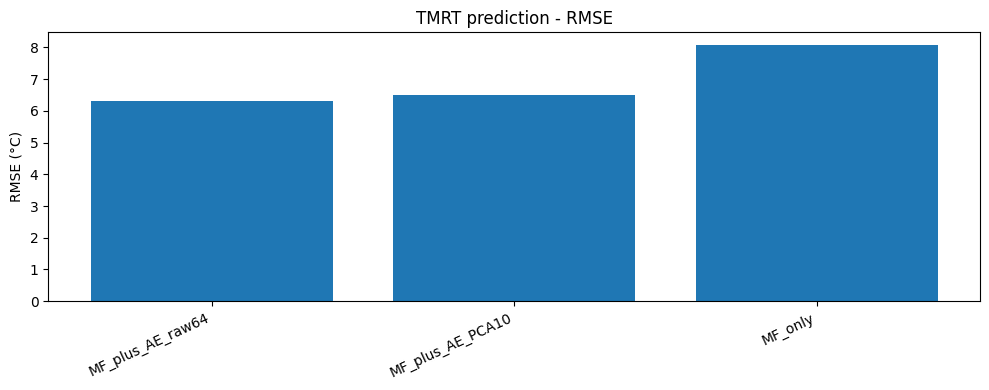

Figure enregistrée: outputs\figures\tmrt_pred\models\rmse_by_set.png


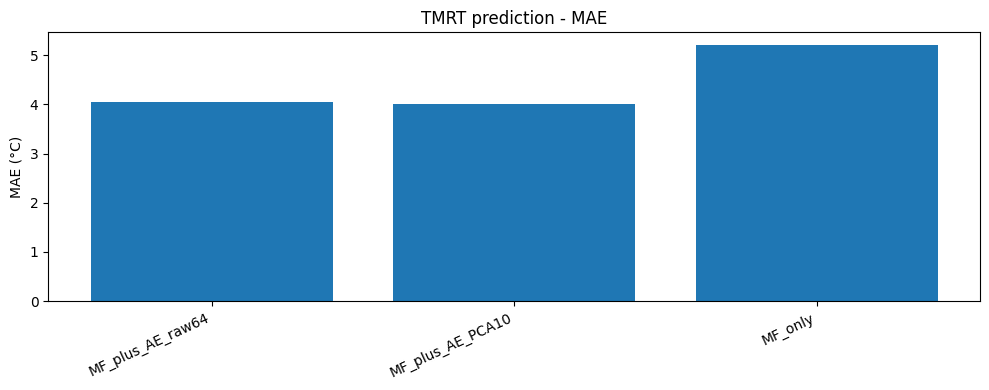

Figure enregistrée: outputs\figures\tmrt_pred\models\mae_by_set.png


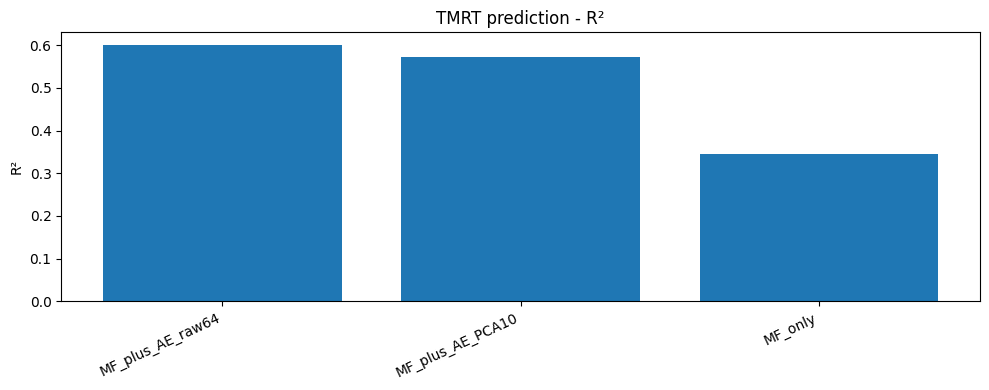

Figure enregistrée: outputs\figures\tmrt_pred\models\r2_by_set.png


In [51]:
plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("RMSE (°C)")
plt.title("TMRT prediction - RMSE")
plt.tight_layout()
out_fig = FIG_MODELS / "rmse_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["mae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("MAE (°C)")
plt.title("TMRT prediction - MAE")
plt.tight_layout()
out_fig = FIG_MODELS / "mae_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["r2"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("R²")
plt.title("TMRT prediction - R²")
plt.tight_layout()
out_fig = FIG_MODELS / "r2_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


In [ ]:
best_set = results_df.iloc[0]["set"]
print("Best set:", best_set)

if best_set == "MF_only":
    feat_cols = mf_features
elif best_set == "MF_plus_AE_PCA10":
    feat_cols = mf_features + ae_pca10
else:
    feat_cols = mf_features + ae_raw

X = train[feat_cols]
y = train[TARGET].astype(float)
tr, te = splits[best_set]

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("reg", HistGradientBoostingRegressor(random_state=42))
])
model.fit(X.iloc[tr], y.iloc[tr])
pred = model.predict(X.iloc[te])

test_rows = train.iloc[te].copy()
test_rows["tmrt_pred"] = pred
test_rows["err"] = test_rows["tmrt_pred"] - test_rows["tmrt"]

print("Test rows:", test_rows.shape)

Best set: MF_plus_AE_raw64
Test rows: (67070, 377)


In [ ]:
pred_csv = MFDATA / f"tmrt_pred_testrows_{best_set}.csv"
test_rows[["uid","timestamp","timestamp_utc","tmrt","tmrt_pred","err","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"]\
         if all(c in test_rows.columns for c in ["uid","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"]) \
         else ["timestamp","timestamp_utc","tmrt","tmrt_pred","err"]].to_csv(pred_csv, index=False)

print("Export test_rows:", pred_csv)

Export test_rows: outputs\tmrt_pred_testrows_MF_plus_AE_raw64.csv


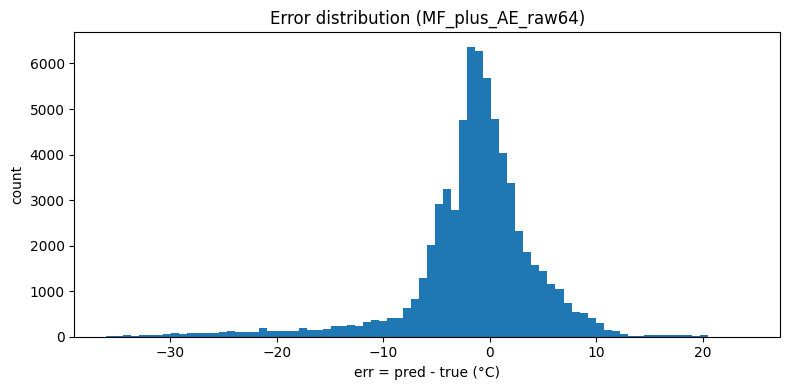

Figure enregistrée: outputs\figures\tmrt_pred\errors\error_hist.png


In [54]:
plt.figure(figsize=(8,4))
plt.hist(test_rows["err"].dropna(), bins=80)
plt.xlabel("err = pred - true (°C)")
plt.ylabel("count")
plt.title(f"Error distribution ({best_set})")
plt.tight_layout()
out_fig = FIG_ERRORS / "error_hist.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


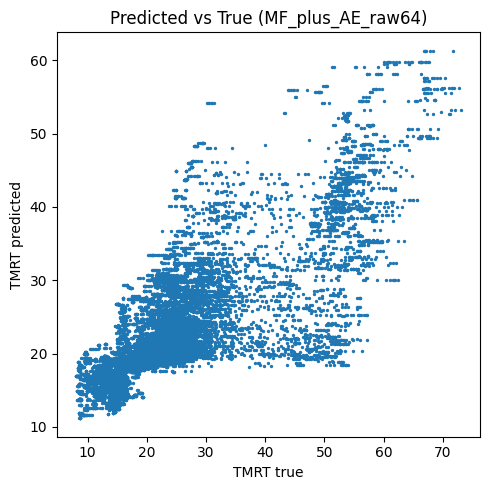

Figure enregistrée: outputs\figures\tmrt_pred\errors\pred_vs_true.png


In [55]:
sample = test_rows.sample(n=min(30000, len(test_rows)), random_state=42)

plt.figure(figsize=(5,5))
plt.scatter(sample["tmrt"], sample["tmrt_pred"], s=2)
plt.xlabel("TMRT true")
plt.ylabel("TMRT predicted")
plt.title(f"Predicted vs True ({best_set})")
plt.tight_layout()
out_fig = FIG_ERRORS / "pred_vs_true.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


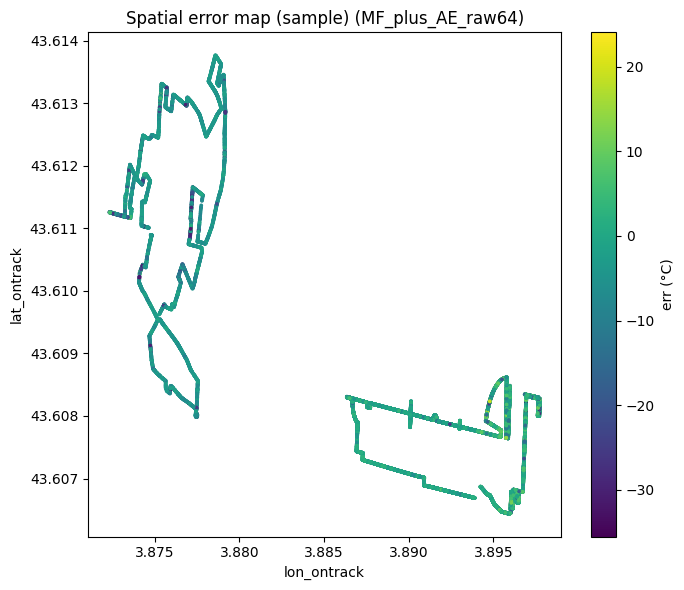

Figure enregistrée: outputs\figures\tmrt_pred\errors\spatial_error_map.png


In [56]:
if {"lon_ontrack","lat_ontrack"}.issubset(test_rows.columns):
    plot_df = test_rows.sample(n=min(20000, len(test_rows)), random_state=42)
    plt.figure(figsize=(7,6))
    plt.scatter(plot_df["lon_ontrack"], plot_df["lat_ontrack"], c=plot_df["err"], s=3)
    plt.colorbar(label="err (°C)")
    plt.xlabel("lon_ontrack")
    plt.ylabel("lat_ontrack")
    plt.title(f"Spatial error map (sample) ({best_set})")
    plt.tight_layout()
    out_fig = FIG_ERRORS / "spatial_error_map.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)
else:
    print("lon_ontrack/lat_ontrack absents")


In [ ]:
err = test_rows["err"].to_numpy()

summary = {
    "set": best_set,
    "n": int(np.sum(~np.isnan(err))),
    "mean_err": float(np.nanmean(err)),
    "median_err": float(np.nanmedian(err)),
    "mae": float(np.nanmean(np.abs(err))),
    "rmse": float(np.sqrt(np.nanmean(err**2))),
    "p05_abs_err": float(np.nanpercentile(np.abs(err), 5)),
    "p50_abs_err": float(np.nanpercentile(np.abs(err), 50)),
    "p95_abs_err": float(np.nanpercentile(np.abs(err), 95)),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

out_csv = MFDATA / "tmrt_pred_error_summary.csv"
summary_df.to_csv(out_csv, index=False)
print("Résumé exporté:", out_csv)

,set,n,mean_err,median_err,mae,rmse,p05_abs_err,p50_abs_err,p95_abs_err
0,MF_plus_AE_raw64,67070,-1.486444,-0.987688,4.049155,6.300362,0.221967,2.474467,13.514051


Résumé exporté: outputs\tmrt_pred_error_summary.csv


group_cols: ['track_id', 'M_slot', 'section_id']


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\693240591.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_err)


,track_id,M_slot,section_id,n,mae,rmse,bias,p95_abs
318,ecusson,M2,62,25.0,29.583196,29.600141,-29.583196,30.431791
322,ecusson,M2,66,50.0,25.471376,25.603151,-25.471376,28.395851
300,ecusson,M2,44,91.0,24.685622,25.516982,-24.685622,30.449644
357,ecusson,M3,33,51.0,25.107246,25.245628,-25.107246,26.737550
258,ecusson,M1,75,107.0,22.793687,23.804400,-22.476955,32.023824
366,ecusson,M3,43,68.0,20.262698,23.054625,-20.262698,33.529256
344,ecusson,M3,16,30.0,21.383274,22.526176,-21.383274,30.496913
333,ecusson,M3,2,45.0,21.382205,21.864988,-21.382205,29.442211
320,ecusson,M2,64,36.0,18.132917,21.063427,-18.132917,34.534923
352,ecusson,M3,27,40.0,18.750792,20.873446,-18.750792,31.120134


Export err_by: outputs\tmrt_pred_error_by_groups.csv


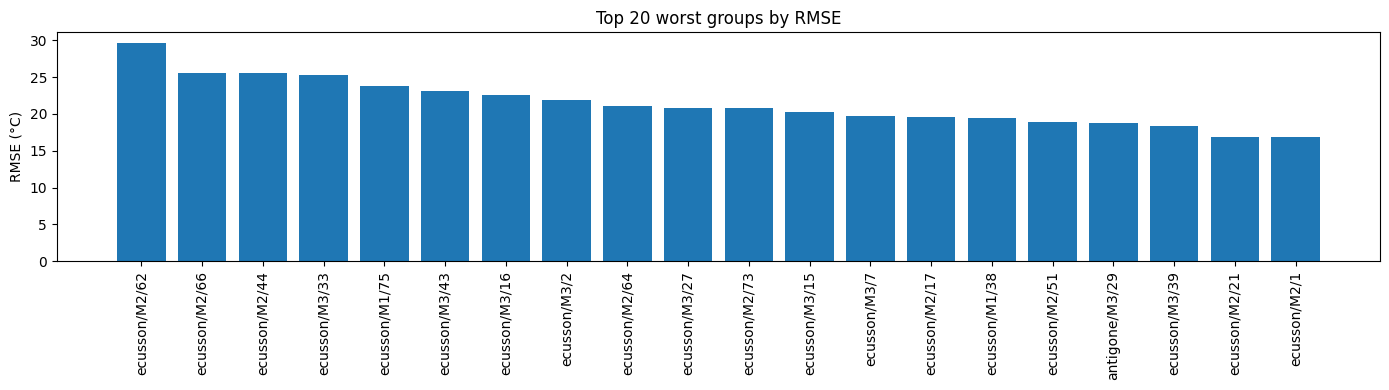

Figure enregistrée: outputs\figures\tmrt_pred\errors\top20_groups_rmse.png


In [ ]:
group_cols = [c for c in ["track_id", "M_slot", "section_id"] if c in test_rows.columns]
print("group_cols:", group_cols)

def agg_err(g):
    e = g["err"].to_numpy()
    return pd.Series({
        "n": len(e),
        "mae": np.mean(np.abs(e)),
        "rmse": np.sqrt(np.mean(e**2)),
        "bias": np.mean(e),
        "p95_abs": np.percentile(np.abs(e), 95)
    })

if group_cols:
    err_by = (test_rows.groupby(group_cols)
              .apply(agg_err)
              .reset_index()
              .sort_values("rmse", ascending=False))

    display(err_by.head(25))

    out_csv = MFDATA / "tmrt_pred_error_by_groups.csv"
    err_by.to_csv(out_csv, index=False)
    print("Export err_by:", out_csv)

    top = err_by.head(20).copy()
    labels = ["/".join(map(str, row)) for row in top[group_cols].values]

    plt.figure(figsize=(14,4))
    plt.bar(range(len(top)), top["rmse"])
    plt.xticks(range(len(top)), labels, rotation=90)
    plt.ylabel("RMSE (°C)")
    plt.title("Top 20 worst groups by RMSE")
    plt.tight_layout()
    out_fig = FIG_ERRORS / "top20_groups_rmse.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)

else:
    print("Pas de colonnes track_id / M_slot / section_id")


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


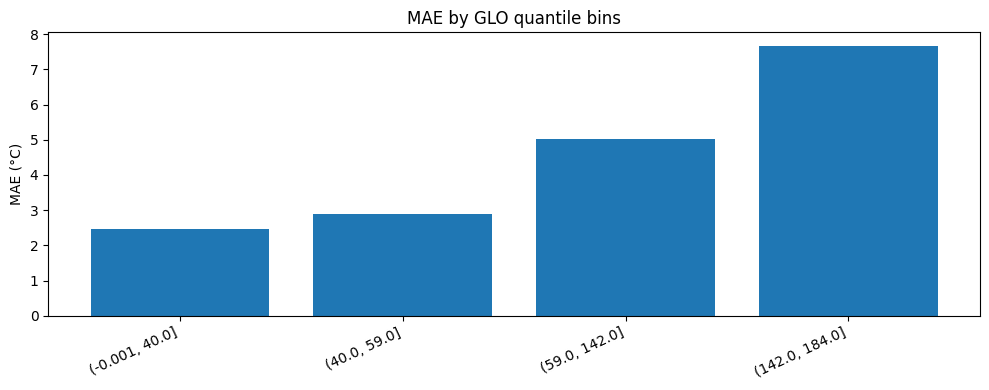

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_GLO_bins.png


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


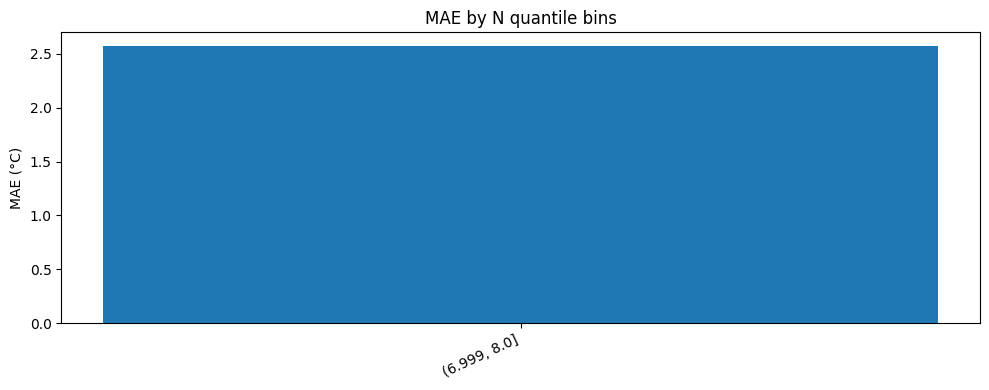

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_N_bins.png


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


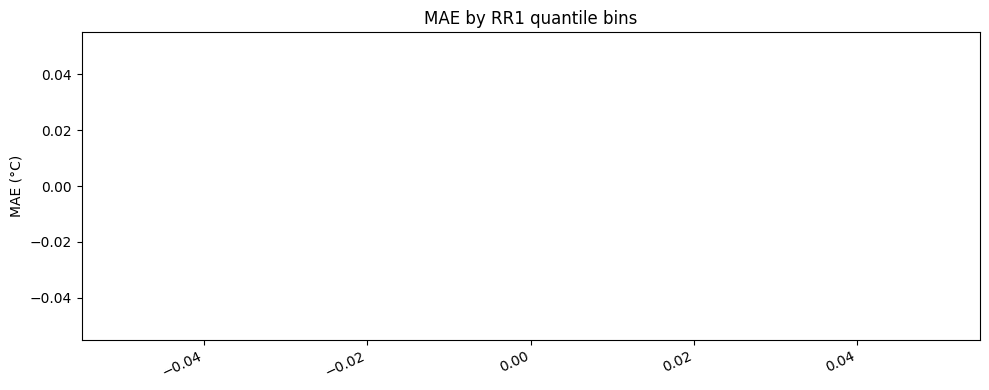

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_RR1_bins.png


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


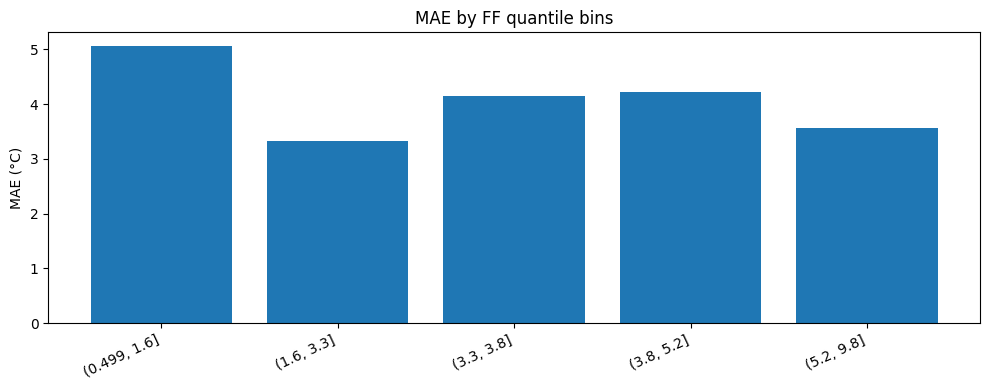

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_FF_bins.png


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


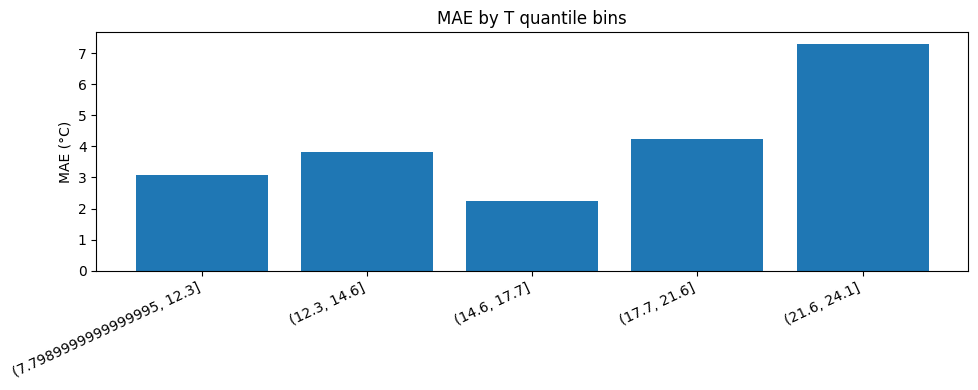

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_T_bins.png


C:\Users\antoc\AppData\Local\Temp\ipykernel_6728\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


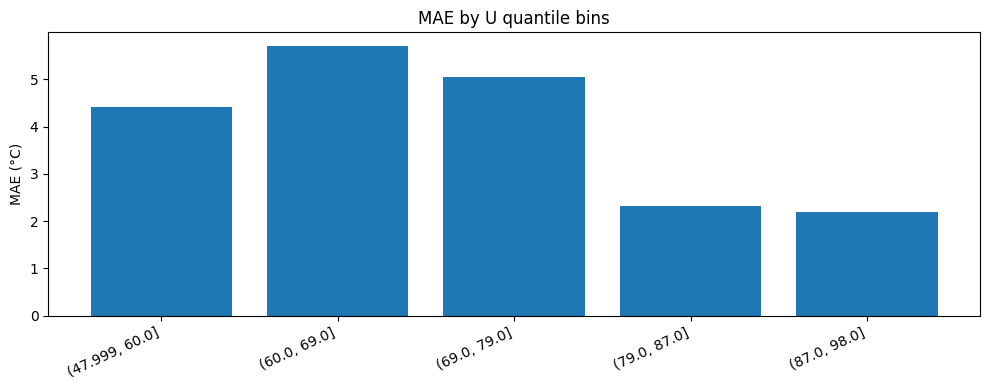

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_U_bins.png


In [59]:
def plot_binned_mae(df_, col, q=5):
    tmp = df_.dropna(subset=[col, "err"]).copy()
    if tmp.empty:
        print("Empty:", col)
        return
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")

    plt.figure(figsize=(10,4))
    plt.bar(tab["bin"].astype(str), tab["MAE"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("MAE (°C)")
    plt.title(f"MAE by {col} quantile bins")
    plt.tight_layout()
    out_fig = FIG_ERRORS / f"mae_by_{col}_bins.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)

for col in ["GLO", "N", "RR1", "FF", "T", "U"]:
    if col in test_rows.columns:
        plot_binned_mae(test_rows, col, q=5)


In [16]:
best_set = results_df.iloc[0]["set"]
print("Best set:", best_set)

if best_set == "MF_only":
    feat_cols = mf_features
elif best_set == "MF_plus_AE_PCA10":
    feat_cols = mf_features + ae_pca10
else:
    feat_cols = mf_features + ae_raw

# Entraînement final sur tout le dataset
X = train[feat_cols]
y = train[TARGET].astype(float)

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("reg", HistGradientBoostingRegressor(random_state=42))
])

model.fit(X, y)
pred_all = model.predict(X)

all_rows = train.copy()
all_rows["tmrt_pred"] = pred_all
all_rows["err"] = all_rows["tmrt_pred"] - all_rows["tmrt"]

print("All rows:", all_rows.shape)

Best set: MF_plus_AE_raw64
All rows: (341281, 377)


In [ ]:
# Tri par uid
sort_cols = [c for c in ["uid", "timestamp"] if c in all_rows.columns]
all_rows_sorted = all_rows.sort_values(sort_cols, kind="stable") if sort_cols else all_rows.copy()

pred_csv = MFDATA / f"tmrt_pred_{best_set}.csv"
all_rows_sorted[
    ["uid","timestamp","tmrt","tmrt_pred","err","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"]
    if all(c in all_rows_sorted.columns for c in ["uid","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"])
    else ["timestamp","tmrt","tmrt_pred","err"]
].to_csv(pred_csv, index=False)

print("Export all_rows:", pred_csv)

Export all_rows: outputs\meteofrance_data\tmrt_pred_MF_plus_AE_raw64.csv
Export all_rows: outputs\meteofrance_data\tmrt_pred_MF_plus_AE_raw64.csv
